## CPSC 4970 - Jonathan Braun - M6 Notebook 1: PCA + Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix

In [2]:
penguins = pd.read_csv("penguins.csv", na_values=["?", "_"])

print("Original shape:", penguins.shape)
print("\nMissing values before dropping:")
print(penguins.isna().sum())

penguins = penguins.dropna().copy()

print("\nCleaned shape:", penguins.shape)
print("\nMissing values after dropping:")
print(penguins.isna().sum())

penguins.head()

Original shape: (344, 7)

Missing values before dropping:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Cleaned shape: (333, 7)

Missing values after dropping:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [3]:
numeric_features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = penguins[numeric_features]
y = penguins["species"]

print(X.head())
print()
print(y.value_counts())

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
0              39.1             18.7              181.0       3750.0
1              39.5             17.4              186.0       3800.0
2              40.3             18.0              195.0       3250.0
4              36.7             19.3              193.0       3450.0
5              39.3             20.6              190.0       3650.0

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


## Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (249, 4)
Testing shape: (84, 4)


## Running PCA

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.68589339 0.19248407]
Total explained variance: 0.8783774606790407


## Dataframe for plotting

In [6]:
train_pca_df = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
train_pca_df["species"] = y_train.to_numpy()
train_pca_df["dataset"] = "Train"

test_pca_df = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"])
test_pca_df["species"] = y_test.to_numpy()
test_pca_df["dataset"] = "Test"

pca_df = pd.concat([train_pca_df, test_pca_df], ignore_index=True)

pca_df.head()

,PC1,PC2,species,dataset
0,0.227714,1.401941,Chinstrap,Train
1,-1.147180,0.285050,Adelie,Train
2,2.395442,0.601064,Gentoo,Train
3,-1.626860,-0.008243,Adelie,Train
4,-0.175236,1.756555,Chinstrap,Train


## PCA scatter plot by species

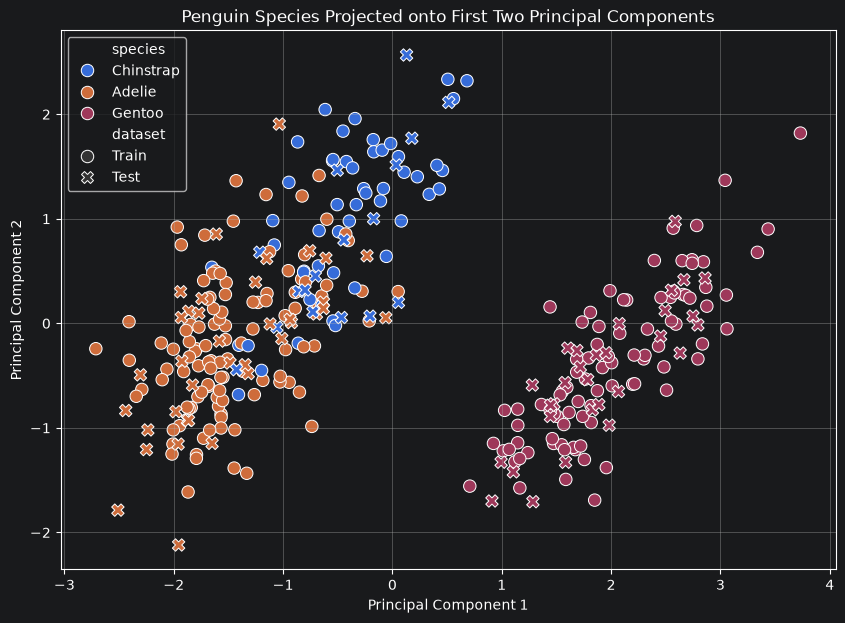

In [7]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    style="dataset",
    s=80
)

plt.title("Penguin Species Projected onto First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

## WSSE and silhouette scores

In [8]:
k_values = range(2, 9)

wsse_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train_pca)

    wsse_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_train_pca, cluster_labels))

metrics_df = pd.DataFrame({
    "k": list(k_values),
    "WSSE": wsse_values,
    "Silhouette Score": silhouette_values
})

metrics_df

,k,WSSE,Silhouette Score
0,2,289.653931,0.613478
1,3,159.751583,0.553698
2,4,107.088167,0.519225
3,5,79.559254,0.461236
4,6,67.776114,0.437305
5,7,56.785043,0.407544
6,8,50.290831,0.401288


## Plot for WSSE

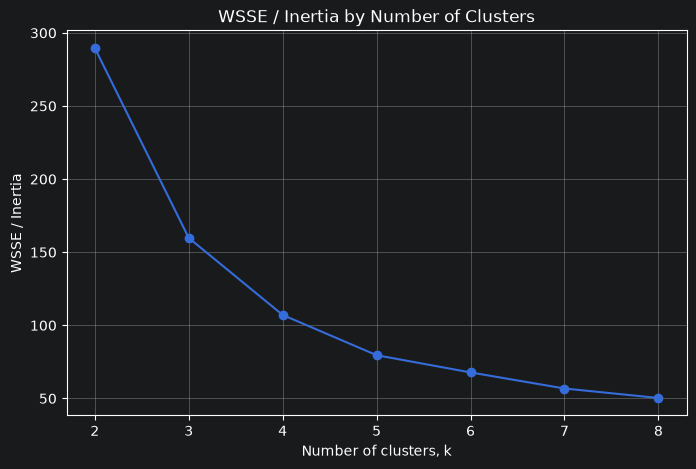

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(metrics_df["k"], metrics_df["WSSE"], marker="o")

plt.title("WSSE / Inertia by Number of Clusters")
plt.xlabel("Number of clusters, k")
plt.ylabel("WSSE / Inertia")
plt.grid(True)
plt.show()

## Plot for silhouette scores

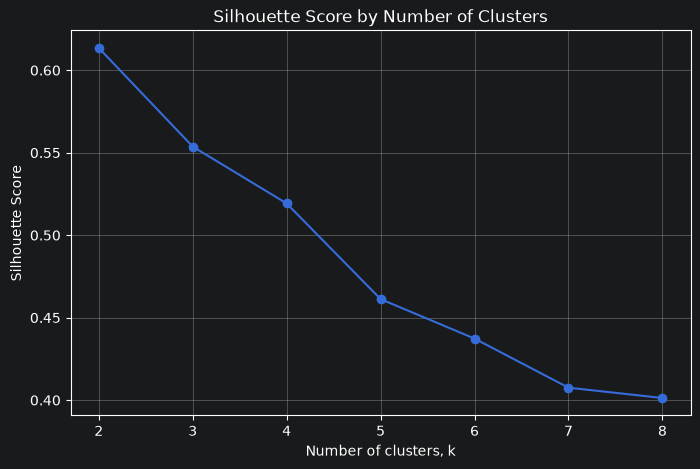

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(metrics_df["k"], metrics_df["Silhouette Score"], marker="o")

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters, k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

## Final K-means with k = 3

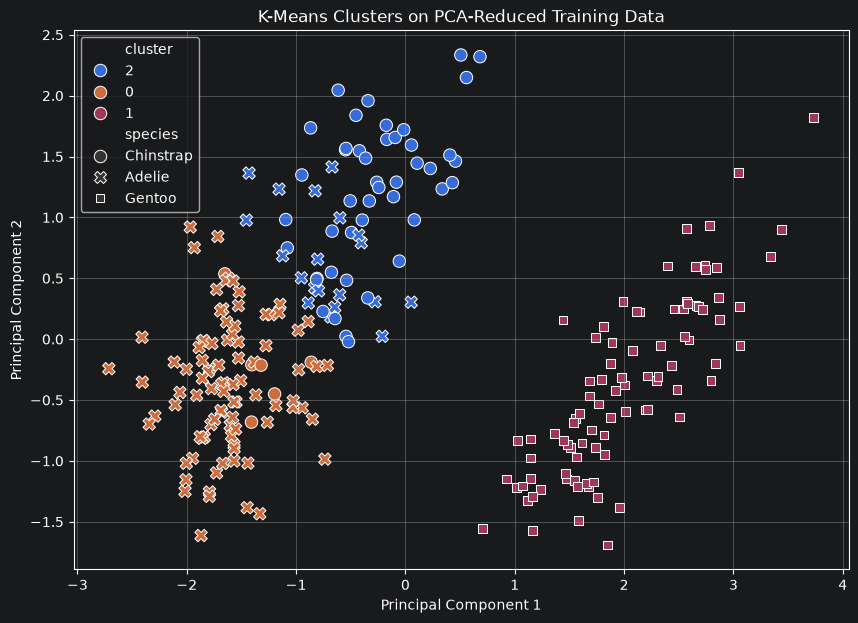

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

train_clusters = kmeans.fit_predict(X_train_pca)
test_clusters = kmeans.predict(X_test_pca)

train_cluster_df = train_pca_df.copy()
train_cluster_df["cluster"] = train_clusters.astype(str)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=train_cluster_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    style="species",
    s=80
)

plt.title("K-Means Clusters on PCA-Reduced Training Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [12]:
cluster_to_species = {}

for cluster in sorted(np.unique(train_clusters)):
    species_in_cluster = y_train.to_numpy()[train_clusters == cluster]
    majority_species = pd.Series(species_in_cluster).value_counts().idxmax()
    cluster_to_species[cluster] = majority_species

cluster_to_species

{np.int32(0): 'Adelie', np.int32(1): 'Gentoo', np.int32(2): 'Chinstrap'}

## Training and testing accuracy

In [13]:
train_pred_species = np.array([cluster_to_species[cluster] for cluster in train_clusters])
test_pred_species = np.array([cluster_to_species[cluster] for cluster in test_clusters])

train_accuracy = accuracy_score(y_train, train_pred_species)
test_accuracy = accuracy_score(y_test, test_pred_species)

print("Training accuracy:", train_accuracy)
print("Testing accuracy:", test_accuracy)

Training accuracy: 0.8955823293172691
Testing accuracy: 0.8571428571428571


## Confusion matrices

In [14]:
species_labels = sorted(y.unique())

train_cm = pd.DataFrame(
    confusion_matrix(y_train, train_pred_species, labels=species_labels),
    index=[f"Actual {label}" for label in species_labels],
    columns=[f"Predicted {label}" for label in species_labels]
)

test_cm = pd.DataFrame(
    confusion_matrix(y_test, test_pred_species, labels=species_labels),
    index=[f"Actual {label}" for label in species_labels],
    columns=[f"Predicted {label}" for label in species_labels]
)

print("Training confusion matrix:")
display(train_cm)

print("Testing confusion matrix:")
display(test_cm)

Training confusion matrix:


,Predicted Adelie,Predicted Chinstrap,Predicted Gentoo
Actual Adelie,89,20,0
Actual Chinstrap,6,45,0
Actual Gentoo,0,0,89


Testing confusion matrix:


,Predicted Adelie,Predicted Chinstrap,Predicted Gentoo
Actual Adelie,27,10,0
Actual Chinstrap,2,15,0
Actual Gentoo,0,0,30


## PCA and clustering conclusion

After dropping rows with missing values, the cleaned dataset contained 333 penguins. I used only the four numerical features required for this part of the assignment: culmen length, culmen depth, flipper length, and body mass. The data was split into a training set of 249 rows and a testing set of 84 rows.

The four numerical features were standardized and then reduced to two dimensions using PCA. The first principal component explained approximately 68.59% of the variance, and the second principal component explained approximately 19.25% of the variance. Together, the first two principal components explained approximately 87.84% of the total variance. This means that the two-dimensional PCA projection preserved most of the structure from the original four numerical features.

The PCA scatter plot shows that Gentoo penguins separate very clearly from the other two species. Adelie and Chinstrap penguins are less completely separated and show some overlap in the PCA space. This suggests that the numerical features are very effective for distinguishing Gentoo penguins, but less perfect for separating Adelie and Chinstrap penguins from each other.

The WSSE plot shows a large decrease from k = 2 to k = 3, followed by more gradual decreases as k increases. This supports k = 3 as a reasonable choice, especially because the dataset contains three species. The silhouette score was highest at k = 2, with a score of approximately 0.6135, while k = 3 had a silhouette score of approximately 0.5537. This makes sense because Gentoo forms a very distinct group, while Adelie and Chinstrap are more similar to one another. Even though the silhouette score prefers k = 2, k = 3 is the most appropriate final choice for this assignment because the goal is to cluster the three penguin species.

Using K-Means with k = 3, the clusters were mapped to species labels based on the majority species in each training cluster. The model achieved a training accuracy of approximately 89.56% and a testing accuracy of approximately 85.71%. The confusion matrices show that Gentoo was classified perfectly in both the training and testing sets. The classification errors occurred only between Adelie and Chinstrap, which matches the overlap seen in the PCA scatter plot.

Overall, the PCA-reduced numerical features produce data that is reasonably conducive to cluster analysis. The clustering separates Gentoo penguins very well, but Adelie and Chinstrap are more difficult to separate perfectly using only these numerical features.